# Train & Evaluate — Cooked Meter Prototype

Trains the three-stage pipeline:
1. **Model A** — TF-IDF + LogisticRegression, predicts `Sentiment` + `Emotion` from review text (trained on Dataset 2 / PRDECT-ID)
2. **Model B** — same architecture, predicts the linguistic reliability flag (trained on Dataset 3's labeled subset) — *added in a later step*
3. **Model C** — `DecisionTreeClassifier`, predicts CS priority from Model A + Model B's outputs + product category — *added in a later step*

Run ahead of time, not live in front of judges (see `notebooks/demo.ipynb` for the live-demo notebook).

In [1]:
import os

if os.path.exists('../src'):
    # Running locally from prototype/notebooks/ — just move cwd up to prototype/
    %cd ..
else:
    # Running on a fresh runtime (e.g. Colab) — clone the repo and cd into prototype/
    !git clone https://github.com/Zikabyte/cooked-meter.git
    %cd cooked-meter/prototype

C:\Users\mzida_yqzansz\Projects\notebooks\cooked-meter\prototype


In [2]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

from config.target_rules import priority_label, category_to_reliability
from src.load_features import load_datasets
from src.preprocess import split_for_leakage_avoidance, train_test_split_simple, build_encoder
from src.text_models import build_text_classifier, fit_and_evaluate

## 1. Load & split Dataset 2

`chunk1` trains + sanity-checks Model A. `chunk2` is held out entirely from Model A's training — its rows are reserved for building Model C's training table later, so Model C only ever sees Model A's honest, out-of-sample predictions (see the plan's leakage-avoidance note).

In [3]:
df2, df3 = load_datasets()

chunk1, chunk2 = split_for_leakage_avoidance(df2, stratify_col="Sentiment", chunk1_size=0.5)
chunk1_train, chunk1_test = train_test_split_simple(chunk1, target_col="Sentiment", test_size=0.2)

print(f"chunk1: {chunk1.shape[0]} rows (train={chunk1_train.shape[0]}, test={chunk1_test.shape[0]})")
print(f"chunk2 (held out for Model C): {chunk2.shape[0]} rows")

chunk1: 2696 rows (train=2156, test=540)
chunk2 (held out for Model C): 2697 rows


## 2. Model A — Sentiment classifier

Trained on `Review_Clean` (lowercase + URL/punctuation cleanup only, no stemming or stopword removal) rather than `Review_Preprocessed`. This is a deliberate choice so `demo.ipynb` can replicate the exact same preprocessing on a judge's live-typed review with a few lines of regex — no need to bring in the Sastrawi stemmer at inference time and risk a train/demo vocabulary mismatch.

In [4]:
sentiment_model = build_text_classifier()
sentiment_model = fit_and_evaluate(
    sentiment_model, chunk1_train, chunk1_test,
    text_col="Review_Clean", target_col="Sentiment",
)

              precision    recall  f1-score   support

    Negative       0.86      0.99      0.92       282
    Positive       0.99      0.83      0.90       258

    accuracy                           0.91       540
   macro avg       0.92      0.91      0.91       540
weighted avg       0.92      0.91      0.91       540



## 3. Model A — Emotion classifier

Same architecture, same train/test rows, different target column. This one has 5 classes instead of 2, so expect lower per-class recall — that's expected and fine to show judges (it's exactly why the priority formula treats emotion as a *weight*, not the sole signal).

In [5]:
emotion_model = build_text_classifier()
emotion_model = fit_and_evaluate(
    emotion_model, chunk1_train, chunk1_test,
    text_col="Review_Clean", target_col="Emotion",
)

              precision    recall  f1-score   support

       Anger       0.57      0.34      0.42        71
        Fear       0.40      0.37      0.38        95
       Happy       0.71      0.84      0.77       179
        Love       0.75      0.42      0.54        79
     Sadness       0.50      0.66      0.57       116

    accuracy                           0.59       540
   macro avg       0.58      0.52      0.54       540
weighted avg       0.60      0.59      0.58       540



## 4. Model B — Linguistic reliability classifier

Trained on the **whole** of Dataset 3 (`df3`), not just the linguistically-labeled subset — unlabeled rows (`tidak_berkategori`) default to `reliable`, so Model B learns a real binary classification task across all ~7,800 rows. Uses `comment` (lightly-cleaned, not stemmed) rather than a heavily preprocessed column, since Model B gets applied cross-domain to Dataset 2's text later, and `Review_Clean` (Dataset 2's lightly-cleaned column) is a closer match in preprocessing level than `Review_Preprocessed` would be.

In [6]:
df3["reliability_flag"] = df3["category"].apply(category_to_reliability)
print(df3["reliability_flag"].value_counts())

df3_train, df3_test = train_test_split_simple(df3, target_col="reliability_flag", test_size=0.2)

reliability_model = build_text_classifier()
reliability_model = fit_and_evaluate(
    reliability_model, df3_train, df3_test,
    text_col="comment", target_col="reliability_flag",
)

reliability_flag
reliable      5973
unreliable    1827
Name: count, dtype: int64
              precision    recall  f1-score   support

    reliable       0.87      0.97      0.92      1195
  unreliable       0.84      0.54      0.66       365

    accuracy                           0.87      1560
   macro avg       0.86      0.75      0.79      1560
weighted avg       0.87      0.87      0.86      1560



## 5. Build Model C's training table (from `chunk2`)

`chunk2` was never shown to Model A, so `sentiment_model`/`emotion_model`'s predictions here are honest out-of-sample outputs — not memorized answers. `reliability_model` is applied cross-domain (trained on Dataset 3 text, applied to Dataset 2 text) since Dataset 2 has no linguistic-category labels of its own.

The **target label** (`priority`) is computed from `chunk2`'s **true** Sentiment/Emotion via `priority_label()` (plus the predicted reliability flag, since there's no ground-truth reliability for Dataset 2 either) — not from the predicted sentiment/emotion. This keeps the label an honest reflection of the EDA's rule, while the **input features** stay exactly what a real deployment would have: predictions, not ground truth.

In [7]:
import pandas as pd

feature_table = pd.DataFrame({
    "predicted_sentiment": sentiment_model.predict(chunk2["Review_Clean"]),
    "predicted_emotion": emotion_model.predict(chunk2["Review_Clean"]),
    "predicted_reliability": reliability_model.predict(chunk2["Review_Clean"]),
    "product_category": chunk2["Category"].values,
})

feature_table["priority"] = [
    priority_label(sentiment, emotion, reliability)
    for sentiment, emotion, reliability in zip(
        chunk2["Sentiment"], chunk2["Emotion"], feature_table["predicted_reliability"],
    )
]

print(feature_table["priority"].value_counts())
feature_table.head()

priority
Low       1399
Medium     682
High       616
Name: count, dtype: int64


,predicted_sentiment,predicted_emotion,predicted_reliability,product_category,priority
0,Positive,Happy,reliable,Electronics,Low
1,Negative,Fear,reliable,Men's Fashion,Medium
2,Positive,Love,reliable,Other Products,High
3,Negative,Fear,reliable,Food and Drink,High
4,Positive,Happy,reliable,Movies and Music,Low


## 6. Model C — Priority `DecisionTreeClassifier`

The interpretable centerpiece: `max_depth=4` keeps it small enough to plot as a flowchart for the live Q&A. Categorical inputs (`predicted_sentiment`, `predicted_emotion`, `predicted_reliability`, `product_category`) are one-hot encoded via `build_encoder` — the encoder is fit on the train split only (not the full table) to avoid leaking test-set categories into it.

In [8]:
CATEGORICAL_COLS = ["predicted_sentiment", "predicted_emotion", "predicted_reliability", "product_category"]

train_table, test_table = train_test_split_simple(feature_table, target_col="priority", test_size=0.2)

encoder = build_encoder(CATEGORICAL_COLS)
X_train = encoder.fit_transform(train_table)
X_test = encoder.transform(test_table)
y_train, y_test = train_table["priority"], test_table["priority"]

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

preds = tree_model.predict(X_test)
print(classification_report(y_test, preds))
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(
    confusion_matrix(y_test, preds, labels=tree_model.classes_),
    index=tree_model.classes_, columns=tree_model.classes_,
))

              precision    recall  f1-score   support

        High       0.76      0.60      0.67       123
         Low       0.88      0.94      0.91       280
      Medium       0.64      0.67      0.66       137

    accuracy                           0.80       540
   macro avg       0.76      0.74      0.75       540
weighted avg       0.79      0.80      0.79       540

Confusion matrix (rows=true, cols=predicted):
        High  Low  Medium
High      74   11      38
Low        3  264      13
Medium    20   25      92


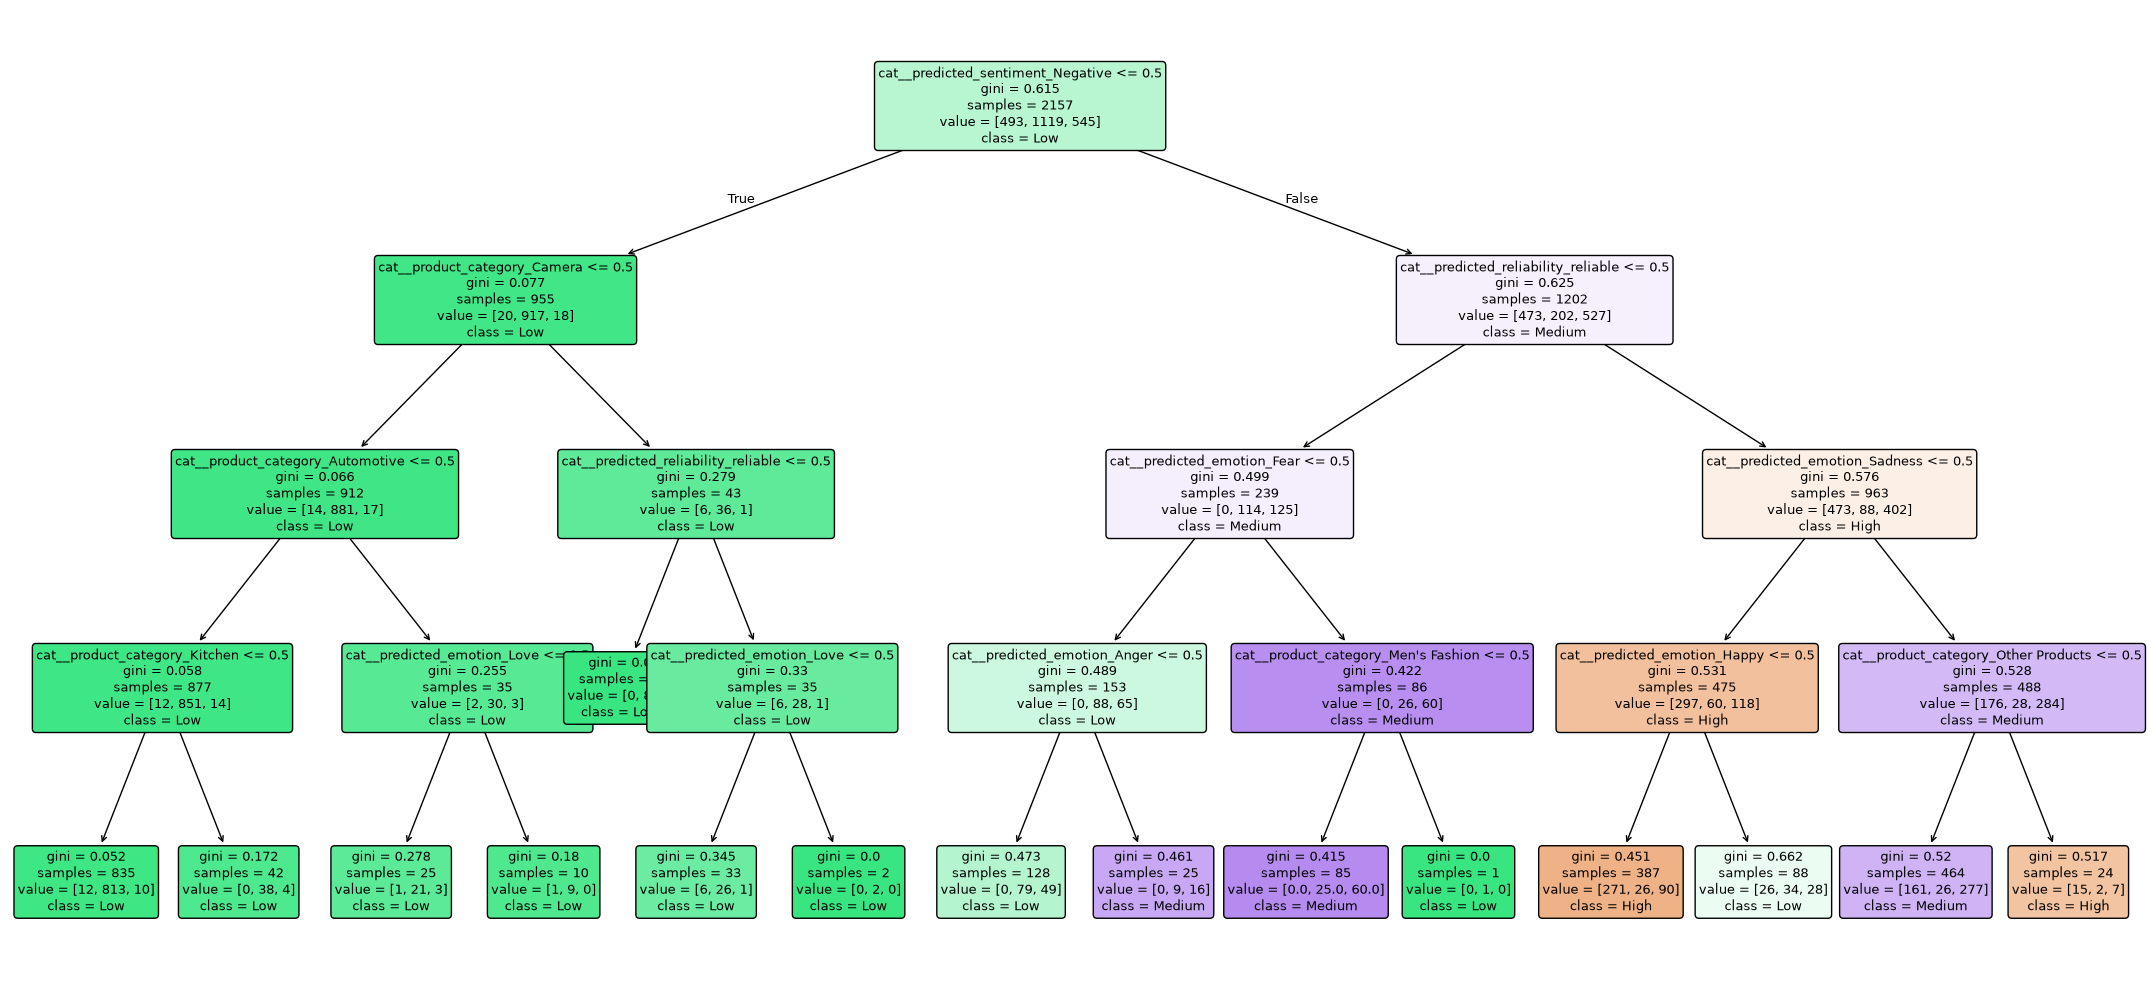

In [9]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=encoder.get_feature_names_out(),
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 7. Save all fitted artifacts

`demo.ipynb` needs all four of these to run the full pipeline (text → priority) without retraining anything live.

In [10]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(sentiment_model, "models/sentiment_model.pkl")
joblib.dump(emotion_model, "models/emotion_model.pkl")
joblib.dump(reliability_model, "models/reliability_model.pkl")
joblib.dump(encoder, "models/feature_encoder.pkl")
joblib.dump(tree_model, "models/priority_tree.pkl")

print("Saved all 5 artifacts to prototype/models/")

Saved all 5 artifacts to prototype/models/
